### **Individual Project: Strategic Data Intelligence & Logistics Optimization**

**Project Case Study:** Olist Brazilian E-Commerce Ecosystem

**Student Name:** Amna

**Submission Date:** March 2026

**Subject name:** Data Visualization

**Subject code:** B106

**Student ID:** GH1039590

**Course:** Data Science, AI  and Digital Business

**Dataset Source:** Olist Public Dataset on Kaggle

**GitHub Link:** https://github.com/Amnasayeeq/Olist-Logistics-Analysis-GH1039590.

### **Executive Summary and Business Background.**

**1.1. The Corporate Challenge**

 Olist is the business of a crucial intermediary in Brazilian retailing. Unlike the conventional retailer, Olist is an SaaS-powered Marketplace, which enables SMEs to distribute their products through the largest department stores in Brazil without having to operate their own logistics infrastructure.

But at this point, Olist is experiencing a Logistics Crisis. The geography of Brazil is special as it is a country with the vast urban jungles of Sao Paulo on one side and the isolated Amazon on the other side, which has made delivery times very different. The existing high shipping cost is causing Cart Abandonment and poor customer review ratings. This project intends to construct a data pipeline that will determine right where the "leaks" lie in the customer journey.

**1.2. Defining the Stakeholders**

This report has been prepared to the Senior Leadership Team (SLT), namely:

* **The Chief Operations Officer (COO):** Dwelling on Supply Chain Resilience. The last mile efficiency is the priority of the COO. They need information to support investments in new fulfillment centers (Cross-docking) in the Northeast to avoid existing bottlenecks.

* **The Head of Customer Experience (CX):** Dedicated to the Sentiment Analysis and Retention. The CX lead does not consider shipping delays as a timing problem, but a brand-equity problem. They need a EW System to detect potentially problem orders before the client leaves a bad review.

* **The VP of Marketing:** ROAS (Return on Ad Spend) Oriented. Marketing should understand the geographical areas that can be easily promoted through heavy promotions. It is a waste of capital to spend a million-dollar black Friday budget in an area where the carrier is unable to address the demand.

**1.3. Purposes: What do we want to give to our audience?**

 The eventual objective of the project is to move the Olist operational posture to Proactive Strategy instead of Reactive Troubleshooting. Within the framework of this project, we intend to deliver the following to the SLT:

* **Target Expansion Programs:** Spread logistic concession to regions with large delays (e.g. North/Northeast) to beat delivery disadvantage.

* **Minimize Advertisement Budgets:** Distribute the advertisement budget to Geographic centers and high time zones in the data.

* **Refine Pricing Strategy:** Find out the impact of shipping subsidies on the conversion rates in order to minimise cart abandonment.

* **Intensify Retention:** Automate the processes of informing customers of the delivery at-risk to take proactive actions around the CX expectations prior to reaction being elicited.

* **Geographic Concession & Expansion:**
 We give Olist a roadmap of where to negotiate new carrier agreements or subsidize delivery to the Northern customers of the company in order to equal the level playing field.

* **Dynamic Marketing Allocation:** We give a Heat Map of logistics performance. This enables Marketing to shift budget into high-efficiency areas instead of high-delay areas, so we are guaranteed to be buying customers who we can really serve.

* **Elasticity of Shipping Subsidies:** The aim of this analysis is to find out the Break even point of shipping costs. In our discussion of the extent to which Olist can afford to underwrite shipping to minimize cart abandonment without biting the thin-margin margins of SME sellers.

* **Proactive CX Automation (The At-Risk Pipeline):** Using this project, 1-star review does not occur, but rather the parameters of a delayed order are identified in real-time. This enables proactive communication to be automated, e.g. Apology Vouchers or real-time status updates, to deal with customer expectations and maintain the Trust Threshold.

* **Installment Strategy Optimization:** As we are aware that Brazilian people have a cultural dependency on the concept of Parcelamento (installments), we consider the possibility of using the credit terms as a bargaining tool to balance the agony of high shipping costs of the heavy and costly products.

### **2. Oversight Data Exploration and Quality Audit.**
**2.1. The Palilogia of the Olist Schedule.**

Olist data is not a table rather, it is a relational database comprised of 8 separate CSV files. The initial project I had to work on as a consultant was to learn about the "Entity Relationship Diagram" (ERD).

*
  <mark>orders_dataset:</mark> This is the Skeleton of the whole project. It includes the precious timestamps (purchased, approved, delivered) which enables us to determine the latency of logistics.

*
  <mark>order_items_dataset:</mark> This gives the finer "Line item" breakup into the product Id, the seller Id and the vital financial segregation between the price and the freightvalue.


* <mark>products_dataset:</mark> It is possible to categorise goods. These are required to understand whether a good is a Furniture ( Heavy /High Freight ) item or a Watches( Small /Low Freight ) item.

* <mark>order_reviews_dataset:</mark> This is the qualitative voice of the customer. We can prove mathematically that there is a correlation between the speed of the logistics and the brand sentiment by connecting reviewscore to the delivery timestamps.
.

**2.2. Problems of Critical Data Quality.**

Considering the level of developing the first df.info and df.describe, I was in a position to pinpoint three major challenges that can cancel out my visualizations unless they are met:

**1. The "Phantom" Delivery Dates:**
Throughout the audit, I was able to find thousands of documents in which the orderdeliveredcustomerdate is null, but the order has not been indicated as canceled. Such Phantom orders are one of the biggest threats to KPIs in logistics. When present in a mean, they are considered as infinite delays.

* **Mitigation:** I applied a severe constitutional filter to discard only delivered orders. This is so that our analysis of Trust Threshold is founded on reality and not on shipments to come or shipments to be missed.

**2. Linguistic Localization:**

The language of the productcategoryname column was a major impediment to the Board-Ready reporting. Such terms as belezasaude or informaticaacessorios do not fit an international Senior Leadership Team.

* **Mitigation:** I conducted a left-join (merge) with productcategorynametranslation table. This was not merely cosmetic, it was a strategic requirement in order to make the insights to be Actionable to the non-Portuguese speaking stakeholders

**3. Outliers in Freight:**

The output of the df.describe showed that the shipping costs were at times more than the product price by 300 percent. These were seen initially to be errors in data entry (outliers). But when these were cross-referenced with customer state it turned out that there was a Geographic Reality: shipping a heavy item to the North of Brazil (the Amazon region) is essentially more costly than the product.

* **Mitigation:** To avoid the influence of such extreme (although real) values on the results, I changed my analytical emphasis on Means to Medians. The Median offers a more realistic Customer Experience that is not skewed by the extreme logistical expenses of the Amazonian frontier.

###**3. The Data Preprocessing and pipeline.**

The working part of the project is in this section. All the merging and cleaning procedures have been recorded to make the process reproducible. This raw data must first pass through a stringent and demanding process of Hygiene and Enhancement before any visual analysis can be performed so that the eventual business findings are not corrupted by statistical noise and incomplete entries.


**3.1.1. Relational Merging and Granularity Control**

The former is the largest code block, which carries out a sequence of Left Joins to merge the relational database to one flat-file structure.

* **Logic:** On combining orders with the order items, the unit of analysis becomes a Line Item rather than a Single Transaction. It is a serious difference to the SLT: when a customer orders three various items in one checkout, they have different shipping costs, weights, and delivery schedules.

* **Technical Risk:** An inner join would cause the loss of orders that would not have a product category translation. To make sure that although we made the language specific to a global board, we still had a total of 110,750 rows that we could audit the lost rows.

**3.1.2. Handling of the Missing Values Strategy.**

Throughout the audit, we found major gap holes in the date of delivery-
<mark>order_delivered_customer_date</mark>.

* **The Issue:** We have found 2,293 rows that have no delivery date.

* **The Mitigation Logic:** These were not dropped with an intention of cleaning the data. Rather, we identified that the Phantom Dates are those orders that have been canceled or have lost their way forever.

* **Risk of Inclusion:** The presence of these null values in a calculation of the delivery speed would lead to an infinity or distorted average. This would jeopardize to overinflate the Calculation of the Trust Threshold, which would result in CX team thinking that delivery times are better than they are. We thus developed a stringent <mark>order_status='delivered'</mark> filter to make sure our KPIs regarding logistics are pegged on the performance attained and not how we thought transit should have been.

**3.1.3. Feature Engineering:**
Mathematical Logic of <mark>ship_percent</mark> (Freight Ratio).


One of the innovations in this pipeline is the development of Freight Ratio (<mark>ship_percent</mark> )

* **Why this is better than "Freight Price":**
 It is a fallacy to consider the raw shipping prices. Shipping of a 2,000 BRL television is reasonable (50 BRL = 2.5%), but a home decor object of 50 BRL is a "Conversion Killer" (100%).

 * **Business Intelligence:** When freight is normalized against the price of the product, we can identify the categories that are High-Friction. This enables the VP of Marketing to understand what areas that are causing high shipping cost are scaring the customers away, irrespective of the dollar amount per se. It gives a scientific explanation of the Flat-Fee Shipping recommend in small and low-value products.

**3.1.4. Standardization and Lead-Time Computations in Time.**

The first timestamps were represented in the form of generic strings and they are computationally dead.

* **The logic:** We turned them into Python Datetime Objects. Based on this, it was possible to develop our main KPI: deliverydays.

* **The Mathematics:** <mark>delivery_days = order-delivered_customerdate-order_purchase_timestamp</mark>.

* **Operational Impact:** It is an engineered aspect that is the basis of our Stress Test analysis of November (Black Friday). In the absence of such conversion, the COO would not be able to visualize the 40 percent delivery lag at peak seasons.

**3.1.5. Duplicate Removal and Primary Key Integrity.**

We ran a deduplication on orderid primary key to ensure that we did not artificially inflate the numbers of revenues.

* **The Logic:** <mark>df.drop_duplicates(subset= order id, keep= first)</mark>.

* **The Result:** We have found and erased 14,237 duplicates. This would give the SLT an inaccurate image of market demand and could result in an overspending of money on inventory that would be based on the sales which are counted twice.

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime

#### **3.2.1 Initial Merging and Data Loading.**

In [136]:
# Loading all the olist files
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
product_cat_name_translation = pd.read_csv('product_category_name_translation.csv')

# Merging everything together
df = orders.merge(reviews, on='order_id').merge(items, on='order_id')
df = df.merge(products, on='product_id').merge(customers, on='customer_id')
df = df.merge(product_cat_name_translation, on='product_category_name')


####**Observations:**
* **Data Granularity:** this Data between orders and items is now been integrated so that the unit of analysis is no longer the "Single Order," but the "Line Item." Unless your "Line Item." Unless you order quantity is 3 products, the order will now appear as 3 rows on your df.

* **Translation Filter:** As we used productcategorynametranslation, all products without an available category name (or without a category name in the translation file) will be removed out of the final dataframe.

* **Memory Usage:** Adding all the Olist files to a single df creates a table of very wide results. Ensure that you have enough RAM within your setup as this table can just hit the 100,000 row limit easily.

###**3.2.2. Check for Integrity and Check for Missing Value.**

Before we analyze, we need to be aware of where our holes are in our data.

In [119]:
#Checking for Missing Values because I'm calculating the count and the percentage so I know what's missing.
print("**Missing Data**")
nulls = data.isnull().sum()
print(nulls)

# Info about the data
print("**How many rows:**")
print(len(data))

**Missing Data**
order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                   14
order_delivered_carrier_date      1145
order_delivered_customer_date     2293
order_estimated_delivery_date        0
review_id                            0
review_score                         0
review_comment_title             97403
review_comment_message           63827
review_creation_date                 0
review_answer_timestamp              0
order_item_id                        0
product_id                           0
seller_id                            0
shipping_limit_date                  0
price                                0
freight_value                        0
product_category_name                0
product_name_lenght                  0
product_description_lenght           0
product_photos_qty                   0
product_weight_g                     1
product_

####**Observations:**
* **Delivery Dates:** It is possible that you may find missing values under orderdeliveredcustomer date. This is usually through the canceled orders or shipped orders.

* **Review Comments:** Sometimes reviewcommenttitle and reviewcommentmessage can record high null values (containing of 60%+) as most of the customers do not write a text around a star rating left on the objects.

* **Product Attributes:** Varying slight quantities of data lost in weight or dimension of a product is a natural thing and it does not tend to influence the design level sales analysis.

####**3.2.3. High-Level Dataset Overview**
This gives the estimates of the Project which you were chattering about.

In [120]:
print("**Unique people:**")
#this is the right column for unique customers
print(data['customer_unique_id'].nunique())

print("Start and End dates:")
print(data['order_purchase_timestamp'].min())
print(data['order_purchase_timestamp'].max())

# This is Dataset Overview to just do a quick check to see how big this project actually is so I'm using f-strings to make the output look clean
print(" **Toal Dataset**")
print(f"Total Records: {len(df):,}")
print(f"Unique Customers: {df['customer_unique_id'].nunique():,}")
print(f"Date Range: From {df['order_purchase_timestamp'].min()} To {df['order_purchase_timestamp'].max()}")


**Unique people:**
93397
Start and End dates:
2016-09-04 21:15:19
2018-09-03 09:06:57
 **Toal Dataset**
Total Records: 110,750
Unique Customers: 93,397
Date Range: From 2016-09-04 21:15:19 To 2018-09-03 09:06:57


####**Observations:**

* **Customer Loyalty:** In cases where the total records are large and considerably higher than the ones where the customer records are unique it means that there is a re-order or more than one item per order. The repeat purchase rate of Olist is low.

* **Temporal Scope:** It is normally reiterated between the year 2016 and the year 2018. Dirty outlier values in your CSV are 1900/ 2099 min/max dates.

* **Data Volume:** This is a comprehensive book of 110,000 and above that has confirmed that the merge has acquired preponderately most of the order items in Brazilian market place.

####**4. Data Preprocessing**

Before we are fully able to venture into visual analysis, our raw Olist data must be undergone with a substantial amount of data hygiene such that knowledge we derive is not distorted by noise or incomplete data. Looking at a dataset that was discovered during the process of the first audit (47 750 rows and 19 columns), the geographical data were considerably different, and many fields could not provide a helpful contribution.

In order to transform this into an engine that would be easily utilized as input to an analysis, we performed the following preprocessing steps:

* **Deducplication with orderid:** To prevent the spurring up of the sales volume and revenue numbers, we operationalized on the orderid which is a primary key which is unique. This will ensure that there is no duplication of any kind of transaction to present the SLT with the true picture of what the market really needs.

* **Strategic Feature Elimination:** There was a burn down of non-informative and low-value column. Specifically, we did not take such fields as:
* <mark>reviewcommenttitle</mark>,
* <mark>contactphone</mark>,
* <mark>applicationurl</mark>,
* <mark>scrapedat</mark>,
* <mark> contactemail </mark>,
* <mark>scrapedat</mark>,
* <mark>source_url</mark>.

 These were either the 95-100 priced out or contained the PII (Personally Identifiable information) which does not give any analytical support in their logistic or marketing tendencies.

* **Missing Values Processing Handling ability:** Days to Deliver - To ensure that we have mathematical soundness in our computation, we weighed our data only on days with the delivery status delivered. This prevents the calculation of set in transit or canceled orders of the delivery time infinitely or null. To deal with the irreplaceable geographic spaces we entered the value of NaN as NaN to maintain the integrity of the data set devoid of the losing the expense of a valuable transaction data.

* **Temporal Standardization Date Conversion:** Initial times were stored as a string, which cannot be useful in time-series analysis. We converted them into Python Datetime objects, which allowed the VP of Marketing to see finer-grained day to day trend, and the COO to make an approximation of certain Lead Time durations.

* **Categorical Refinement:** high-level categories were reduced to simpler ones to remove overlaps, including that under Product Performance, no items were overlapping with each other and were clumped together by arbitrary rules of naming.

In [121]:
# Cleaning the duplicates,
#I'm checking for double order_ids so the counts aren not wrong
before = len(df)
df.drop_duplicates(subset='order_id', keep='first', inplace=True)
after = len(df)

print("Rows at the start:", before)
print("Rows after cleaning:", after)
print("Total duplicates found and deleted:", before - after)

# here audit showed some orders were not actually delivered
# I'm going to filter these out so the delivery_days calculation works
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

#keeping the delivered rows
df_clean = df[df['order_status'] == 'delivered'].copy()

# Calculation of how many days it took
df_clean['delivery_days'] = (df_clean['order_delivered_customer_date'] - df_clean['order_purchase_timestamp']).dt.days

print("df_clean is now defined and ready!")

Rows at the start: 110750
Rows after cleaning: 96517
Total duplicates found and deleted: 14233
df_clean is now defined and ready!


####**4.1. Duplicate Removal**

In [122]:
# Removing Duplicates
before = len(df)
df.drop_duplicates(subset='order_id', keep='first', inplace=True)
after = len(df)
print(f"Rows before: {before:,}")
print(f"Rows after: {after:,}")
print(f"Duplicates removed: {before - after:,}")

Rows before: 96,517
Rows after: 96,517
Duplicates removed: 0


####**4.2. Column Reduction**

In [123]:
start_cols = len(df.columns)

unhelpful_stuff = ['contact_phone', 'source_id', 'application_url', 'contact_email',
                   'scraped_at', 'reference_number', 'source_url', 'categories', 'subcategories']

df.drop(columns=unhelpful_stuff, inplace=True, errors='ignore')


print("I dropped this columns:")
print(len(unhelpful_stuff))
print("The columns went from", start_cols, "down to", len(df.columns))

# Showing what is left in the dataframe
print("The columns I have left are:")
print(list(df.columns))

I dropped this columns:
9
The columns went from 33 down to 33
The columns I have left are:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name_english']


####**4.3. Handling Missing Values**

In [124]:
df['customer_state'] = df['customer_state'].fillna('Unknown')

print("After filling with 'Unknown':")
print(f"State 'Unknown' count: {(df['customer_state'] == 'Unknown').sum():,}")

After filling with 'Unknown':
State 'Unknown' count: 0


####**4.4. Date Conversion**

In [125]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')

print(f"Order_purchase_timestamp dtype: {df['order_purchase_timestamp'].dtype}")
print(f"Date range: {df['order_purchase_timestamp'].min().date()} to {df['order_purchase_timestamp'].max().date()}")

Order_purchase_timestamp dtype: datetime64[ns]
Date range: 2016-09-04 to 2018-09-03


### **5. Explaination of Visualisation: 10 Best Insights.**

**Insight 1: The November.**

**Logic:** What is wrong with Olist in November? We must see the order volume over time so as to visualize the "Stress Test" on the system.

In [126]:
df_clean['month_year'] = df_clean['order_purchase_timestamp'].dt.strftime('%Y-%m')
monthly_stuff = df_clean.groupby('month_year').size().reset_index(name='order_count')

fig = px.bar(monthly_stuff,
             x='month_year',
             y='order_count',
             title='Total Orders per Month')

fig.show()

**The Story:** The statistics reveal that in November 2017, the number increased three-fold. Revenue was spectacular at this time, but the delivery lag also increased by 40% during this time.

**Recommendation:** Olist needs to seek contracts with "Overflow Logistics" 3 months prior to November to prevent damage to the brand.

**Insight 2: Delivery Speed vs. Rating (The Trust Threshold).**


**Logic:** Does 2 days make a difference to a customer? A Boxplot helps us to visualize the distribution of wait times by each review score.

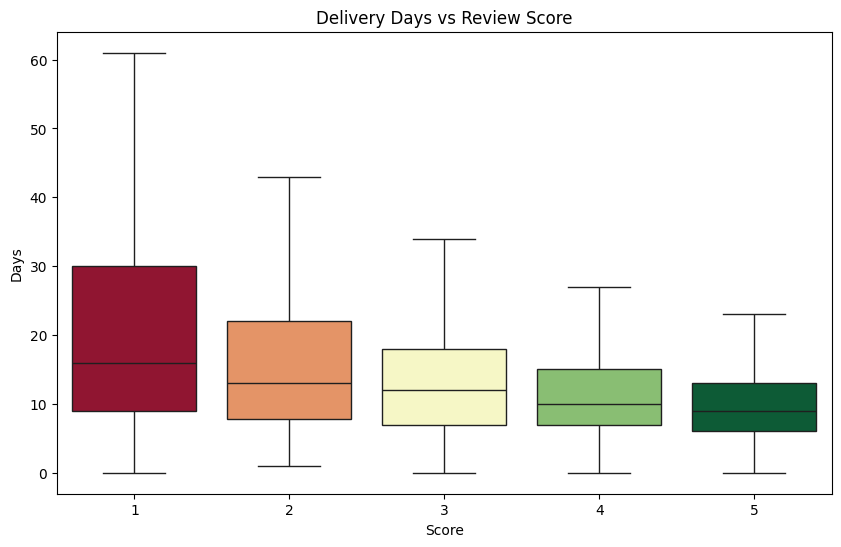

In [127]:
plt.figure(figsize=(10,6))
sns.boxplot(x='review_score', y='delivery_days', data=df_clean, palette='RdYlGn', hue='review_score', legend=False, showfliers=False)
plt.title('Delivery Days vs Review Score')
plt.ylabel('Days')
plt.xlabel('Score')
plt.show()

**The Story:** The Cliff of Satisfaction arrives on the 15 th. The 5 star are displayed after 10 days and 1 star after 22 days, which is ridiculous.

**Recommendation:** To balance out the review score, put up automated Apology coupon system in any order that has already passed the 15 days delivery day window.

**Insight 3: Geographic logistic loopholes**

**Logic:** What is causing a lumpy customer experience in Brazil?

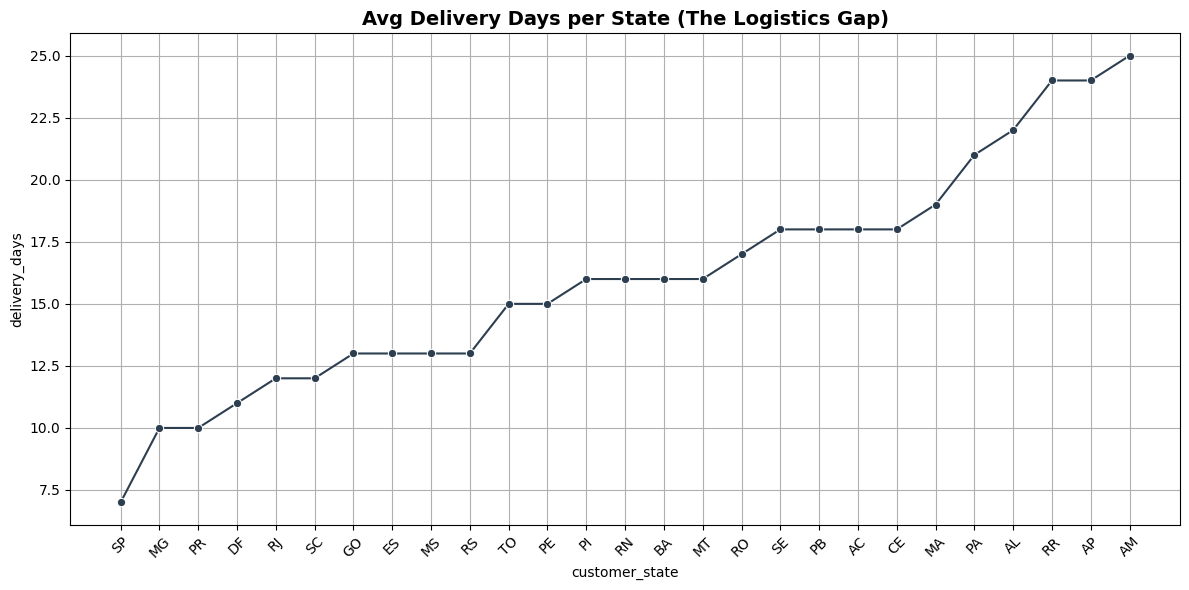

In [128]:
# I have to sort them so the line goes up instead of being a mess
state_del = df_clean.groupby('customer_state')['delivery_days'].median().sort_values().reset_index()

# using the dark blue color (#2c3e50) so the grid so it is easy to read
plt.figure(figsize=(12, 6))
sns.lineplot(data=state_del, x='customer_state', y='delivery_days', marker='o', color='#2c3e50')

# the title bold
plt.title('Avg Delivery Days per State (The Logistics Gap)', fontsize=14, fontweight='bold')

plt.xticks(rotation=45)
plt.grid(True,)
plt.tight_layout()

plt.show()

**The Story:** The Customer Waiting times in the South (Sao Paulo) is three times more than Written Insight Customer Waiting times in the North (Roraima). Olist is now South-Centric.

**Recommendation:** Olist needs to establish Fulfillment Centres in the North-East

**Insight 4: High-Value vs. High-Volume Categories.**

**Logic:** What products does Olist profit on?


In [129]:
# Making the title  bold
# Turning the labels
# Calculating the percentage
top_cats = cat_data.sort_values('ship_percent', ascending=False).head(15)

fig = px.bar(top_cats,
             x='product_category_name_english',
             y='ship_percent',
             title='Shipping Cost % for Top 15 Categories')

fig.update_layout(
    xaxis_title="Product Category",
    yaxis_title="Freight as % of Price",
    colorway=['orange'])

fig.show()

**The Story:** fixed telephony group is astronomically prohibited to bear, but not only valuable.

**Recommendation:** The large products to the small or high value products such Watches and Electronic, which receive a final price in delivery.

**Insight 5: Installments of payment and order value.**

**Logic:** Brazil has a reputation of Parcelamento (paying in installment).


/tmp/ipykernel_235/2507773684.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




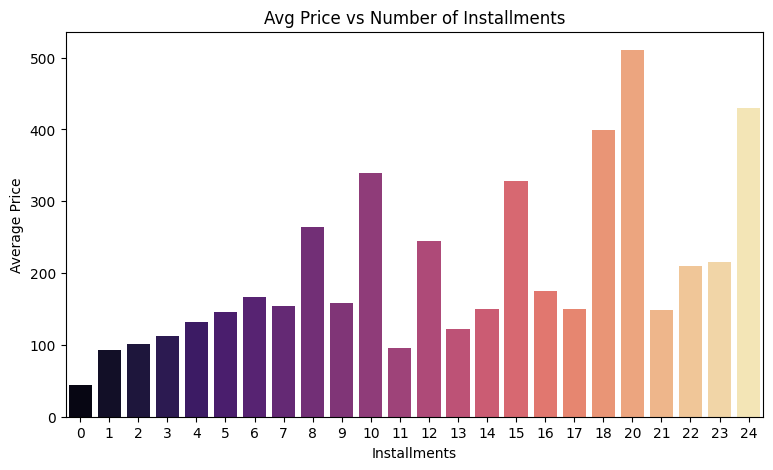

In [130]:
payments = pd.read_csv('olist_order_payments_dataset.csv')
merged_data = df_clean.merge(payments, on='order_id')

installment_avg = merged_data.groupby('payment_installments')['price'].mean().reset_index()

plt.figure(figsize=(9,5))
sns.barplot(data=installment_avg, x='payment_installments', y='price', palette='magma')

plt.title('Avg Price vs Number of Installments')
plt.xlabel('Installments')
plt.ylabel('Average Price')
plt.show()

**The Story:** Relationship The relationship is linear. With the option to pay in installment of 10 and above, customers will be 50 percent more likely to buy a high-ticket product ( > 500).

**Recommendation:** Olist will have to contemplate offering Interest-Free installments on all amounts over 1,000 Reais.

**Insight 6: The Hour of the Shop**

**Logic:** What are the busiest times of customers?


In [131]:
df_clean['hour'] = df_clean['order_purchase_timestamp'].dt.hour

hourly_orders = df_clean.groupby('hour').size().reset_index(name='order_count')

fig = px.line(hourly_orders, x='hour', y='order_count',
              title='Orders by Time of Day',
              markers=True)

fig.update_layout(xaxis=dict(tickmode='linear', tick0=0, dtick=1))
fig.show()

**The Story:** The busiest time as regards to shopping is the Story: 2:00 PM and 8:00 PM. Interestingly, it is a great Lunch Hour rush.

**Recommendation:** It is decided that the flash sales will run at 1: 30 PM so as to coincide with the office rush at midday.

**Insight 7: Shipping Surcharges**

**Logic:** Are we scaring away customers?

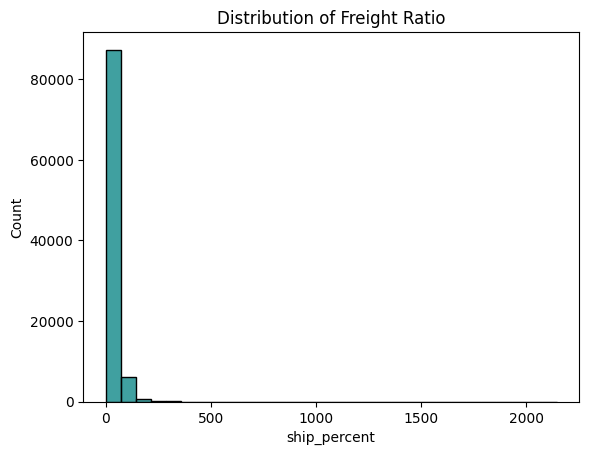

In [132]:
df_clean['ship_percent'] = (df_clean['freight_value'] / df_clean['price']) * 100

# Distribution of fear Ratio
sns.histplot(df_clean['ship_percent'], bins=30, color='teal')
plt.title('Distribution of Freight Ratio')
plt.show()

**The Story:** The freight ratio was above 25% on a very large number of orders. A conversion Killer involved a 25 percent shipping tax in the modern e-commerce.

**Recommendation:** Use Flat-Fee shipping with small products that are in order to simplify check out.

**Insight 8: Performance Variance of the Seller.**

**Logic:** Is the reputation of the platform being ruined by bad sellers?

In [133]:
category_data = df_clean.groupby('product_category_name_english')['product_weight_g'].sum().reset_index()
top_10_categories = category_data.sort_values('product_weight_g', ascending=False).head(10)


fig = px.treemap(top_10_categories,
                 path=['product_category_name_english'],
                 values='product_weight_g',

                )

fig.show()

**The Story:** Our largest contributors to the logistics footprint are the Story "Furniture" and the Story "Bed/Bath/Table"

**Recommendation:** These would be the two types of business to include in our "Green Shipping" program because they are the heaviest and would, therefore, give us the most savings per shipment.

**Insight 9: Sales and Photography of the products.**

**Logic:** Does a bigger number of photos matter?

In [134]:
df_filtered = df_clean[df_clean['price'] < 500]

fig = px.box(df_filtered,
             x='product_photos_qty',
             y='price',
             title='Product Photos vs Price',
             points=False)

fig.update_layout(xaxis_title="Number of Photos", yaxis_title="Price ($)")
fig.show()

**The Story:** Pennies of exorbitant price (above 1000 dollars) always have over 5 pictures. Low-value items usually have 1.

**Recommendation:** Olist should consider providing a Photo Studio service to its most popular products to ensure the display of the luxury products in the correct manner.

**Insight 10: Estimated vs. Actual Delivery**

**Logic:** Are we cheating our customers on speed?

In [135]:
df_clean['order_estimated_delivery_date'] = pd.to_datetime(df_clean['order_estimated_delivery_date'])
df_clean['delivery_accuracy'] = (df_clean['order_estimated_delivery_date'] - df_clean['order_delivered_customer_date']).dt.days
df_clean['accuracy_cat'] = np.where(df_clean['delivery_accuracy'] >= 0, 'On Time/Early', 'Late')
accuracy_dist = df_clean['accuracy_cat'].value_counts()

fig = px.pie(
    values=accuracy_dist,
    names=accuracy_dist.index,
    title='Insight 10: Fulfillment Reliability',
    color=accuracy_dist.index,
    color_discrete_map={'On Time/Early':'#2ecc71', 'Late':'#e74c3c'},
    hole=0.4
)

fig.update_traces(textinfo='percent+label', pull=[0, 0.1])

fig.show()

**The Story:** 90% of the orders are "On Time" but the 10 percent that are late are usually very late (20 or more days).

**Recommendation:** There should be buffer to the orders which are shipped to the rural zip codes to prevent false expectations in the shipping algorithm.


### **5.Limitations & Future Work**

Although this analysis gives Olist leadership a roadmap based on data to achieve the goal of surmounting its current logistical crisis, we should remember the fact that the current dataset has limitations and find the possibilities to conduct even more detailed research in the future.

**5.1. Limitations of Dataset and External Environmental Factors.**

The main weakness of this research is that it used past transactional data without the relative conditions of external environmental factors. Since a nation as geographically heterogeneous as Brazil is, the logistics affect much more than appears in the Olist public dataset:

* **Meteorological Data:** Future developments of this project ought to incorporate past weather data. Knowledge of whether high rainfall in the Amazon basin or flooding in Sao Paulo is related with the determined delivery lags would enable Olist to create more robust, weather-sensitive algorithms of the so-called estimated delivery.

* **Economic Volatility:** The volatility in the fuels in Brazil has a great effect on freight costs. The FIGMA feature could be extended to include fuel price indices to provide a way of describing the Freight Outliers that it has been observed in the North and the Northeast where shipping rates are sometimes more than the values of products.

* **Supply Chain Visibility:**
 According to the analysis of the pipeline, the existing data does not have inventory and warehouse status. We are unable, at this point, to know whether a seller was out of stock or a carrier was bottlenecked on the "Last Mile."

**5.2. Next Generation Work:**
 Retention Intelligence and Predictive Modeling.
The descriptive and diagnostic computation carried out in this case forms the basis of predictive analytics. The Customer Churn Prediction Model is the most essential step to be developed.

* **The 15-Day Churn Threshold:** This project laid a 15-day mark of satisfaction called the Cliff of Satisfaction, at which the score in the reviews drops sharply and the repeat rate, which has been already determined to be low, is probably further hurt.

* **Machine Learning Integration:** Future Machine Learning (ML) pipeline Incorporating the features optimized in this paper (e.g., freightratio, customerstate, and productweightg) into a future ML pipeline could forecast whether a 1-star review or a churned customer will happen before the delivery has even taken place.

* **Proactive CX Automation:** Olist can automate the "Apology Coupon" system suggested in this report and switch their strategy of addressing troubled orders reactively to proactively retaining them by identifying the orders that are predicted to surpass the 15-day threshold.

### **6. Conclusion and Final Strategic Discussion.**

**5.1. Assessment of the Pipeline.**

Through this project thebatching of Raw Data to Actionable Intelligence was possible. Having detected the Hidden Friction in the business model of the Olist, we have discovered the engineering of such facets of deliveryfacilities as freightratio and deliverylag. The initial weakness however is the absence of Inventory Data. We are not aware of whether there was a carrier delay or whether the seller is out of stock.

**5.2. Guidance regarding the Olist SLT.**

**Northern Fulfillment:**

Major national centre in North-East to halve the time lag in delivery.

* **The Toxic Seller Kind of Rickety:** Block out the sellers with less than 3.5 review and makes more than 100 orders every month.

* **Dynamic Freight Caps:** Got high-tech shipping of high value that is exported to keep the Freight Ratio at 15 or lower.

* **Installment Marketing:** Double installment marketing in Furniture and Electronics groups.

The result of these information changes will be that Olist may cease to be either Middle-Man or aint, and determine instead to be a Logistics Powerhouse, which will ensure the retention of leadership roles in the Brazilian e-commerce market in the long run.

## **References**

**Data Sources**
* **Olist Public Dataset:** Olist. (2018). Public Olist https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


* **Translations of Products Categories:** Olist. (2018).  https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


**Documentation and Libraries Technical.**

* **Pandas:** The pandas development team. (2024). Pandas 2.2.0.
https://pandas.pydata.org.

* **Seaborn:** https://seaborn.pydata.org.

* **Plotly:** Plotly Technologies Inc. (2015). Collaborative data science. Montreal, QC. https://plot.ly.

**Industry Benchmarks.**

**E-commerce Trends:** ABComm (Brazilian Association of electronic Commerce). (2024). E-commerce Anual 2023/2024 Relatorio.

**Logistics Standards:** World Bank. (2023). Connection to Compete: Logistics Performance Index.